In [2]:
# importing library

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:
# Creating Required Folders

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/predictions", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("Folders Created Successfully!")

Folders Created Successfully!


In [4]:
# Loading Dataset

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7043
Columns : 21


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [13]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
(df["Churn"].value_counts(normalize=True)*100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [15]:
summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Datatype": df.dtypes
})

summary.to_csv("../outputs/dataset_summary.csv")

In [16]:
# Convert TotalCharges to Numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Missing values handled successfully!")

Missing values handled successfully!


In [19]:
df.drop_duplicates(inplace=True)

print("Duplicate rows removed!")

Duplicate rows removed!


In [20]:
df.drop("customerID", axis=1, inplace=True)

print("customerID column removed!")

customerID column removed!


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Churn"] = le.fit_transform(df["Churn"])

In [22]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("Binary encoding completed!")

Binary encoding completed!


In [23]:
df = pd.get_dummies(df, drop_first=True)

print("One-hot encoding completed!")

One-hot encoding completed!


In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [25]:
print(df.shape)

(7043, 31)


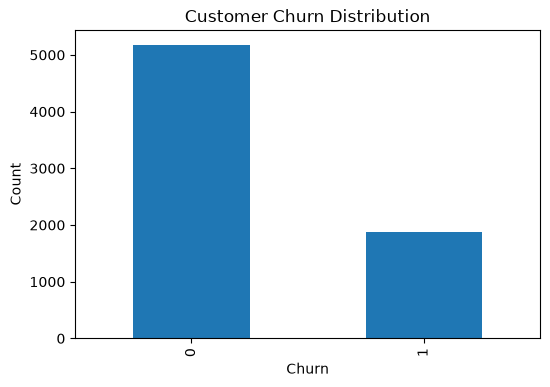

In [26]:
plt.figure(figsize=(6,4))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.savefig("../outputs/figures/churn_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

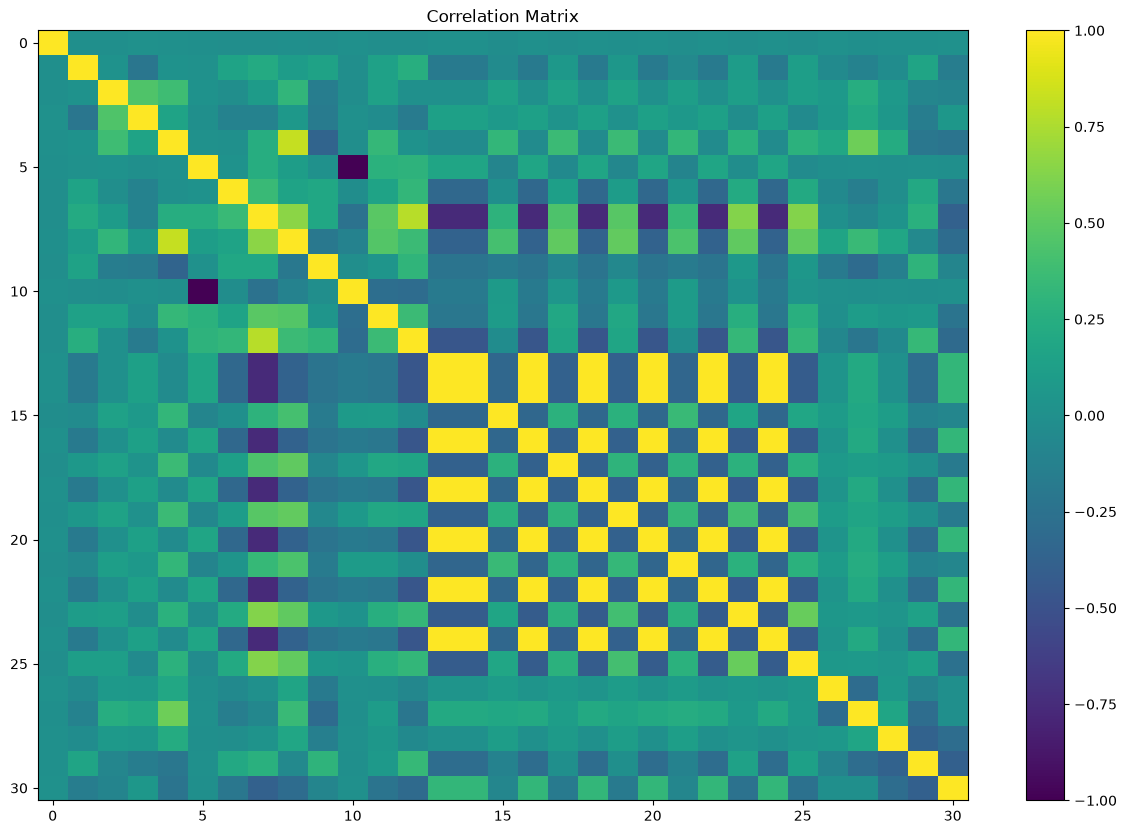

In [27]:
plt.figure(figsize=(15,10))

plt.imshow(df.corr(), aspect="auto")

plt.colorbar()

plt.title("Correlation Matrix")

plt.savefig("../outputs/figures/correlation_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

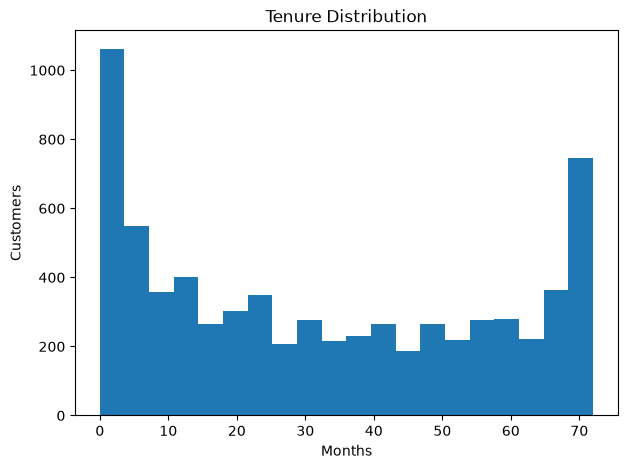

In [28]:
plt.figure(figsize=(7,5))

plt.hist(df["tenure"], bins=20)

plt.title("Tenure Distribution")
plt.xlabel("Months")
plt.ylabel("Customers")

plt.savefig("../outputs/figures/tenure_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

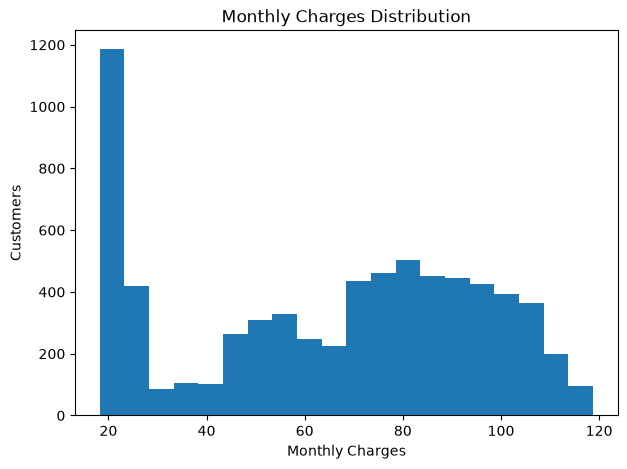

In [29]:
plt.figure(figsize=(7,5))

plt.hist(df["MonthlyCharges"], bins=20)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges")

plt.ylabel("Customers")

plt.savefig("../outputs/figures/monthly_charges_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

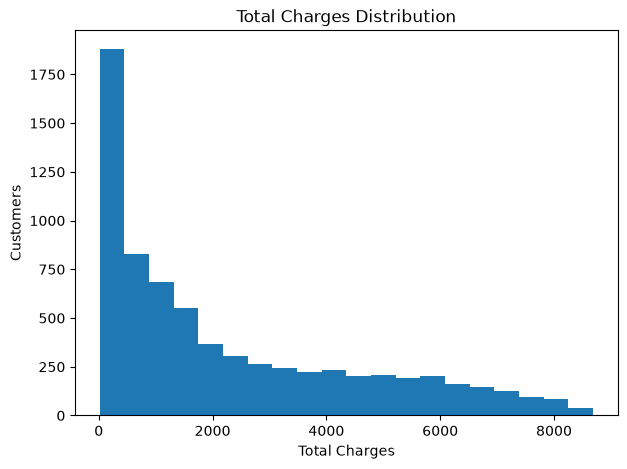

In [30]:
plt.figure(figsize=(7,5))

plt.hist(df["TotalCharges"], bins=20)

plt.title("Total Charges Distribution")

plt.xlabel("Total Charges")

plt.ylabel("Customers")

plt.savefig("../outputs/figures/total_charges_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [31]:
df.to_csv("../data/processed/processed_telco_churn.csv",
          index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [88]:
# Features and Target
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

X = df[features]
y = df["Churn"]

In [89]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (5634, 8)
Testing Features : (1409, 8)
Training Labels : (5634,)
Testing Labels : (1409,)


In [90]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [91]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Model Trained!")

Logistic Regression Model Trained!


In [92]:

# Decision Tree


from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Model Trained!")

Decision Tree Model Trained!


In [93]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained!")

Random Forest Model Trained!


In [94]:
# Accuracy Comparison

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy :", lr_accuracy)
print("Decision Tree Accuracy       :", dt_accuracy)
print("Random Forest Accuracy       :", rf_accuracy)

Logistic Regression Accuracy : 0.7885024840312278
Decision Tree Accuracy       : 0.7281760113555713
Random Forest Accuracy       : 0.7792760823278921


In [95]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

comparison

,Model,Accuracy
0,Logistic Regression,0.788502
2,Random Forest,0.779276
1,Decision Tree,0.728176


In [96]:
comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [97]:
# Import Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [98]:

# Performance Metrics


print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.7885024840312278
Precision: 0.6357142857142857
Recall   : 0.47593582887700536
F1 Score : 0.5443425076452599


In [99]:
# Classification Report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



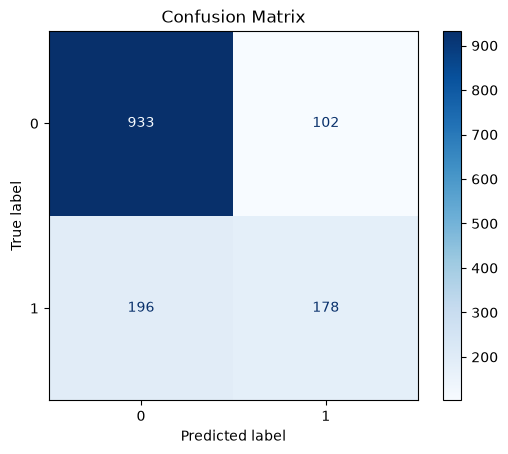

In [100]:


# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "../outputs/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

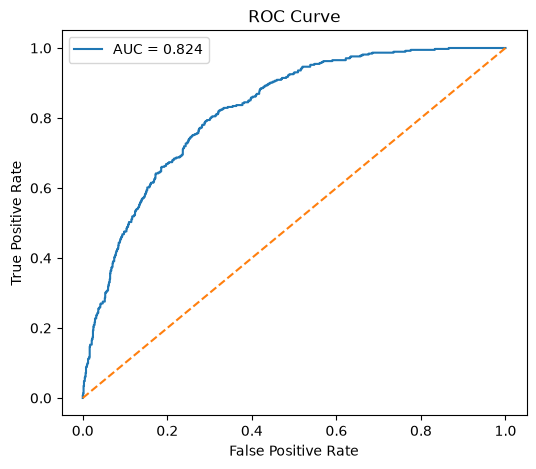

In [101]:
# ROC Curve

y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "../outputs/figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [102]:
# Feature Importance

feature_importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,MonthlyCharges,0.335044
2,TotalCharges,0.321701
0,tenure,0.242423
7,PaperlessBilling,0.032327
3,SeniorCitizen,0.020773
5,Dependents,0.019887
4,Partner,0.019269
6,PhoneService,0.008577


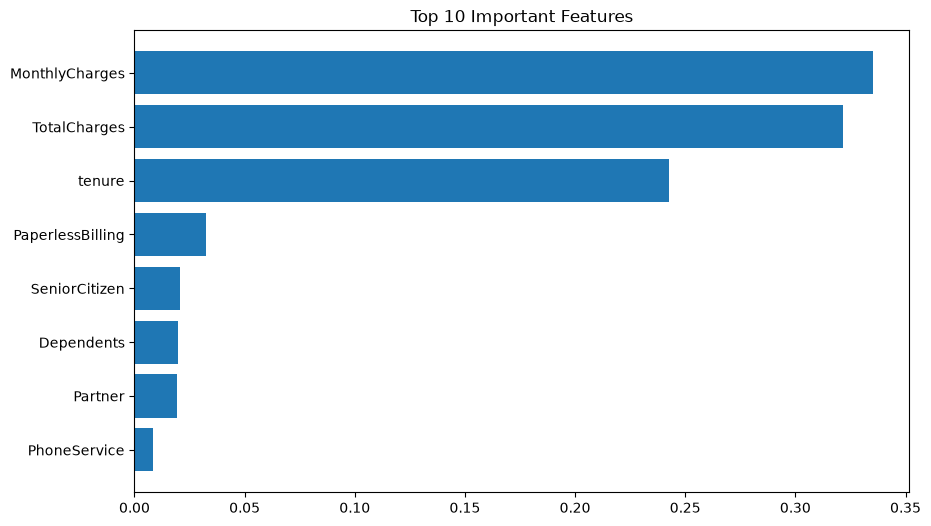

In [103]:
plt.figure(figsize=(10,6))

plt.barh(

    feature_importance["Feature"][:10],

    feature_importance["Importance"][:10]

)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.savefig(

    "../outputs/figures/feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [104]:
feature_importance.to_csv(

    "../outputs/feature_importance.csv",

    index=False

)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [105]:
summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ],

    "Value":[

        accuracy_score(y_test,lr_pred),

        precision_score(y_test,lr_pred),

        recall_score(y_test,lr_pred),

        f1_score(y_test,lr_pred),

        roc_auc_score(y_test,y_prob)

    ]

})

summary

,Metric,Value
0,Accuracy,0.788502
1,Precision,0.635714
2,Recall,0.475936
3,F1 Score,0.544343
4,ROC AUC,0.823870


In [106]:
summary.to_csv(

    "../outputs/model_performance.csv",

    index=False

)

print("Performance report saved!")

Performance report saved!


In [107]:
# Save Best Model

import joblib

joblib.dump(lr_model, "../models/customer_churn_model.pkl")

print("Customer Churn Model Saved Successfully!")

Customer Churn Model Saved Successfully!


In [116]:
# Save Scaler

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [109]:
# Save Feature Columns

joblib.dump(list(X.columns), "../models/feature_columns.pkl")

print("Feature Columns Saved Successfully!")

Feature Columns Saved Successfully!


In [110]:
# Save Predictions

predictions = pd.DataFrame({

    "Actual": y_test,

    "Predicted": lr_pred

})

predictions.to_csv(

    "../outputs/predictions/churn_predictions.csv",

    index=False

)

print("Predictions Saved Successfully!")

Predictions Saved Successfully!


In [111]:
# Predict Sample Customer

sample_customer = X_test.iloc[[0]]

sample_scaled = scaler.transform(sample_customer)

prediction = lr_model.predict(sample_scaled)

probability = lr_model.predict_proba(sample_scaled)

print("Prediction :", "Churn" if prediction[0] == 1 else "No Churn")

print("Probability :", probability)

Prediction : No Churn
Probability : [[0.88984771 0.11015229]]


In [112]:
# Load Saved Model

loaded_model = joblib.load("../models/customer_churn_model.pkl")

loaded_scaler = joblib.load("../models/scaler.pkl")

print("Saved Model Loaded Successfully!")

Saved Model Loaded Successfully!


In [113]:
sample_scaled = loaded_scaler.transform(sample_customer)

prediction = loaded_model.predict(sample_scaled)

print("Prediction using Saved Model :", prediction)

Prediction using Saved Model : [0]


In [114]:
print("=" * 50)
print("TELCO CUSTOMER CHURN PREDICTION")
print("=" * 50)

print(f"Dataset Shape        : {df.shape}")
print(f"Training Samples     : {X_train.shape[0]}")
print(f"Testing Samples      : {X_test.shape[0]}")

print()
print("Model Performance")
print("-" * 50)

print(f"Logistic Regression : {lr_accuracy:.4f}")
print(f"Decision Tree       : {dt_accuracy:.4f}")
print(f"Random Forest       : {rf_accuracy:.4f}")

print()
print("Best Model : Logistic Regression")

print("=" * 50)

TELCO CUSTOMER CHURN PREDICTION
Dataset Shape        : (7043, 31)
Training Samples     : 5634
Testing Samples      : 1409

Model Performance
--------------------------------------------------
Logistic Regression : 0.7885
Decision Tree       : 0.7282
Random Forest       : 0.7793

Best Model : Logistic Regression


In [115]:
print(list(X.columns))

['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


In [119]:
import joblib

joblib.dump(lr_model, "../models/customer_churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
